In [16]:
!pip install python-dotenv langchain langchain-core langchain-community langchain-google-genai chromadb langchain-text-splitters beautifulsoup4 sentence-transformers einops langchainhub langsmith faiss-cpu pydantic rank_bm25 sentence-transformers 
!pip install langchain-google-vertexai


[notice] A new release of pip is available: 26.0 -> 26.0.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 26.0 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [17]:
# In terminal google cloud vertex ai setup
    # !curl https://sdk.cloud.google.com | bash
    # ! gcloud auth application-default login
# !curl "https://aiplatform.googleapis.com/v1/publishers/google/models/gemini-3-flash-preview:streamGenerateContent?key=AQ.Ab8RN6KRw3jXG5kRUuBmsznpQwBfAKRXGyorHhDhg_c7TmxCwQ" -X POST -H "Content-Type: application/json" -d '{"contents":[{"role":"user","parts":[{"text":"Explain how AI works in a few words"}]}]}'


## Declaration

In [18]:
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.documents import Document
from langchain_core.output_parsers import JsonOutputParser
import transformers
import json
import numpy as np
import os
import warnings
from dotenv import load_dotenv
from pydantic import BaseModel
from typing import List
from langchain_community.retrievers import BM25Retriever
from langgraph.graph import StateGraph, END
from pydantic import BaseModel
from typing import TypedDict, List
from sentence_transformers import CrossEncoder
from langchain_community.embeddings import HuggingFaceEmbeddings
from langchain_community.vectorstores import Chroma
import time
import vertexai
from langchain_google_vertexai import ChatVertexAI
from sklearn.metrics.pairwise import cosine_similarity



load_dotenv()
# google_api_key = os.getenv("GOOGLE_API_KEY")
langchain_api_key = os.getenv("LANGCHAIN_API_KEY")
hf_token = os.getenv("HUGGINGFACEHUB_API_TOKEN")
os.environ["LANGCHAIN_TRACING_V2"] = "true"
os.environ["LANGCHAIN_ENDPOINT"] = "https://api.smith.langchain.com"
warnings.filterwarnings("ignore")



class QueryOutput(BaseModel):
    rewritten_query: str
    expanded_queries: List[str]
    step_back_query: str

class QueryOptimizerOutput(BaseModel):
    rewritten_query: str
    expanded_queries: List[str]
    step_back_query: str

class GraphState(TypedDict):
    query: str
    rewritten_query: str
    expanded_queries: List[str]
    step_back_query: str
    documents: List[Document]
    answer: str
    claims: List[str]                 # NEW
    plan: dict                        # NEW
    iteration: int
    retrieval_feedback: dict
    doc_scores: List[float]


### Models

In [19]:
vertexai.init(project="pleet-d8210", location="global")
llm_compression = ChatVertexAI( model="gemini-3-flash-preview" )
llm = ChatVertexAI( model="gemini-3-flash-preview" )

structured_llm = llm.with_structured_output(QueryOutput)
cross_encoder = CrossEncoder("cross-encoder/ms-marco-MiniLM-L-6-v2")
embeddings = HuggingFaceEmbeddings(model_name="nomic-ai/nomic-embed-text-v1",model_kwargs={"trust_remote_code": True})


Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: cross-encoder/ms-marco-MiniLM-L-6-v2
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
<All keys matched successfully>


In [20]:
import random

def safe_llm_invoke(llm, prompt, retries=5):
    last_error = None

    for i in range(retries):
        try:
            return llm.invoke(prompt)
        except Exception as e:
            last_error = e
            wait_time = (2 ** i) + random.uniform(0, 1)
            print(f"[Retry {i+1}] Waiting {wait_time:.2f}s →", repr(e))
            time.sleep(wait_time)

    raise last_error

## Query Rewritting & Expansion

* User Query  ->  Query Rewriting  ->  Step-Back Query  ->  Query Expansion


| Step      | Why                                      |
| --------- | ---------------------------------------- |
| Rewrite   | cleans the query and removes ambiguity   |
| Step-back | captures **higher-level concept**        |
| Expansion | generates **multiple search variations** |


In [21]:
optimizer_prompt = ChatPromptTemplate.from_messages([
    ("system", "You are an expert query optimizer. Return ONLY JSON."),
    ("human", """
        User Query:
        {query}

        Perform:
        1. Rewrite query
        2. Generate 3 variations
        3. Generate step-back query

        Return JSON:

        {{
        "rewritten_query": "...",
        "expanded_queries": ["...", "...", "...", "..."],
        "step_back_query": "..."
        }}
    """)
])

def query_intelligence_node(state):

    iteration = state.get("iteration", 0)

    # PASS 1 (normal)
    if iteration == 0:
        query = state["query"]

        prompt = optimizer_prompt.invoke({
            "query": query
        })

    # PASS 2 (feedback-driven)
    else:
        feedback = state.get("retrieval_feedback", {})

        snippets = [
            doc.page_content[:200] 
            for doc in state.get("documents", [])[:2]
        ]

        refined_query = f"""
            Previous retrieval failed.

            Reason: {feedback.get("reason")}
            Max Score: {feedback.get("max_score")}
            Avg Score: {feedback.get("avg_score")}

            The following snippets were retrieved but are NOT relevant:
            {chr(10).join(snippets)}

            IMPORTANT:
            - These snippets are incorrect or irrelevant
            - Do NOT base your query on them
            - Use them only to understand what went wrong

            Original Query:
            {state["query"]}

            Previous Rewritten Query:
            {state.get("rewritten_query")}

            Previous Expanded Query:
            {state.get("expanded_queries")}

            Previous Step_back Query:
            {state.get("step_back_query")}

            Your task:
            - Identify why retrieval failed
            - Fix the query without drifting away from user intent
            - Preserve original intent strictly
            - Improve specificity and keywords
        """
        
        prompt = optimizer_prompt.invoke({
            "query": refined_query
        })

    result = safe_llm_invoke(structured_llm,prompt)
    # print("Query: ",state["query"])
    # print("Rewritten_query: ",result.rewritten_query)
    # print("Expanded_queries: ",result.expanded_queries)
    # print("Step_back_query: ",result.step_back_query)

    return {
        "rewritten_query": result.rewritten_query,
        "expanded_queries": result.expanded_queries,
        "step_back_query": result.step_back_query
    }




## VECTOR-DB, EMBEDDINGS & INGESTION

In [22]:

documents = [
    Document(page_content="RAG systems retrieve relevant documents before generating responses."),
    Document(page_content="Faithfulness evaluates whether the generated answer is supported by retrieved context."),
    Document(page_content="Context compression reduces token usage by filtering irrelevant information."),
    Document(page_content="Query expansion improves recall by generating multiple query variations."),
    Document(page_content="Re-ranking models help sort retrieved documents by relevance."),
    Document(page_content="Dense retrieval uses vector embeddings to find similar documents."),
    Document(page_content="Sparse retrieval relies on keyword matching like BM25."),
    Document(page_content="Hybrid retrieval combines dense and sparse methods for better performance."),
    Document(page_content="Hallucination occurs when a model generates unsupported or incorrect information."),
    Document(page_content="Grounded generation ensures responses are based only on retrieved data."),
    Document(page_content="Cross-encoders are often used for re-ranking retrieved documents."),
    Document(page_content="Latency increases when more documents are retrieved and processed."),
    Document(page_content="Chunking splits large documents into smaller pieces for retrieval."),
    Document(page_content="Overlapping chunks can preserve context across boundaries."),
    Document(page_content="Embedding models convert text into numerical vector representations."),
    Document(page_content="Top-k retrieval selects the most relevant k documents."),
    Document(page_content="Temperature controls randomness in language model outputs."),
    Document(page_content="Evaluation metrics for RAG include faithfulness, relevance, and answer correctness."),
    Document(page_content="My favorite color is blue."),
    Document(page_content="The Eiffel Tower is located in Paris."),
    Document(page_content="Some retrieved documents may be irrelevant to the query."),
    Document(page_content="Query rewriting can clarify ambiguous user questions."),
    Document(page_content="Not all retrieved context is useful for answering a query."),
    Document(page_content="Large context windows increase cost but may improve answer quality."),
    Document(page_content="My name is still unknown."),
]

vectorstore = Chroma.from_documents(
    documents=documents,
    collection_name="verirag-chroma",
    embedding=embeddings,
)

vector_retriever = vectorstore.as_retriever(search_kwargs={"k": 5})
bm25_retriever = BM25Retriever.from_documents(documents)
bm25_retriever.k = 5

## RETRIEVER

In [23]:
# Retrieve top 5 results from both BM25 and Vector retrievers, then deduplicate results
def hybrid_retrieve_node(state):
    queries = (
        [state["rewritten_query"]] +
        state["expanded_queries"] +
        [state["step_back_query"]]
    )

    all_docs = []
    print("----------------------------")
    for q in queries:
        print("Query: ",q)
        all_docs.extend(bm25_retriever.invoke(q))
        all_docs.extend(vector_retriever.invoke(q))
        print(all_docs)
        
    print("----------------------------")
    # Deduplicate
    unique_docs = list({doc.page_content: doc for doc in all_docs}.values())

    return {"documents": unique_docs}

## Cross Encoder & Re-Ranking

In [24]:
# Rerank retrieved documents using cross-encoder, normalised scores and filter out low-relevance docs based on a threshold
def rerank_and_filter_node(state):

    docs = state.get("documents", [])
    query = state["query"]

    if not docs:
        return {
            "documents": [],
            "answer": "I don't know",
            "retrieval_feedback": {"reason": "no_docs"}
        }

    pairs = [(query, doc.page_content) for doc in docs]
    scores = cross_encoder.predict(pairs)
    scores = 1 / (1 + np.exp(-scores))

    doc_scores = list(zip(docs, scores))
    doc_scores.sort(key=lambda x: x[1], reverse=True)

    top_docs = doc_scores[:5]
    top_scores = [score for _, score in top_docs]
    max_score = max(top_scores)
    avg_score = sum(top_scores) / len(top_scores)
    print(top_scores, max_score, avg_score)
    print("----------------------------")

    print("rerank: ",[doc for doc, _ in top_docs])
    print("--------------------------------------")

    upper_threshold = 0.7
    lower_threshold = 0.4
    

    if max_score < lower_threshold:
        print("below lower threshold")
        return {
            "documents": [doc for doc, _ in top_docs],
            "answer": "I don't know"
        }

    elif max_score < upper_threshold:
        print("below upper threshold")
        return {
            "documents": [doc for doc, _ in top_docs],
            "doc_scores": top_scores,
            "retrieval_feedback": {
                "reason": "low_relevance",
                "max_score": float(max_score),
                "avg_score": float(avg_score)
            }
        }
    else:
        print("above upper threshold")
        return {
            "documents": [doc for doc, _ in top_docs],
            "doc_scores": top_scores
        }

In [25]:
def Retry_decision_logic(state):

    iteration = state.get("iteration", 0)
    max_iterations = 2

    if state.get("retrieval_feedback") != None and iteration < max_iterations:
        return "retry"

    # If no docs → retry
    if not state.get("documents") and iteration < max_iterations:
        return "retry"

    return "generate"

def Refine_query_node(state):
    return {
        "iteration": state.get("iteration", 0) + 1
    }

## Compression Node

In [26]:
def extract_text(response):
    content = response.content

    if isinstance(content, list):
        return " ".join([item.get("text", "") for item in content]).strip()
    
    return content.strip()


def compress_documents_node(state):

    query = state["query"]
    docs = state.get("documents", [])[:3]

    if not docs:
        return {"documents": []}

    # Embed query once
    query_embedding = embeddings.embed_query(query)

    compressed_docs = []

    total_original_tokens = 0
    total_compressed_tokens = 0

    for doc in docs:

        text = doc.page_content

        # Rough token count (interview acceptable approximation)
        total_original_tokens += len(text.split())

        # Step 1: sentence splitting (simple but effective)
        sentences = [s.strip() for s in text.split(".") if len(s.strip()) > 10]

        if not sentences:
            compressed_docs.append(doc)
            continue

        # Step 2: embed sentences
        sentence_embeddings = embeddings.embed_documents(sentences)

        # Step 3: similarity scoring
        scores = cosine_similarity(
            [query_embedding],
            sentence_embeddings
        )[0]

        # Step 4: pick top-k sentences
        top_k = min(3, len(sentences))

        top_indices = np.argsort(scores)[-top_k:]
        top_indices = sorted(top_indices)  # preserve order

        selected_sentences = [sentences[i] for i in top_indices]

        compressed_text = ". ".join(selected_sentences)

        total_compressed_tokens += len(compressed_text.split())

        compressed_docs.append(Document(page_content=compressed_text))

    # 🔥 LOGGING (THIS is what impresses interviewers)
    print("📉 Compression Stats:")
    print(f"Original tokens: {total_original_tokens}")
    print(f"Compressed tokens: {total_compressed_tokens}")

    if total_original_tokens > 0:
        reduction = 1 - (total_compressed_tokens / total_original_tokens)
        print(f"Reduction: {reduction:.2%}")
    
    return {"documents": compressed_docs}





## Answer Planning Node

In [27]:
def answer_planning_node(state):

    query = state["query"]
    docs = state.get("documents", [])

    if not docs:
        return {"plan": {}}

    # Context already compressed → good
    context = "\n\n".join([doc.page_content for doc in docs])

    prompt = f"""
You are a planning engine for a RAG system.

You MUST create a plan. Do NOT return empty fields.

Given:
Question: {query}
Context: {context}

Instructions:

1. ALWAYS break the query into at least 2 sub-questions
2. ALWAYS extract key information needed
3. ALWAYS map context to sub-questions
4. ALWAYS generate expected factual claims

Even if the query is simple:
- still create meaningful sub-questions
- still extract claims

Rules:
- Use ONLY the given context
- Keep claims atomic and factual

Return STRICT JSON:

{{
  "sub_questions": ["...", "..."],
  "required_info": ["...", "..."],
  "evidence_mapping": [
    {{
      "sub_question": "...",
      "relevant_context": "..."
    }}
  ],
  "expected_claims": ["...", "..."]
}}
"""
    response = safe_llm_invoke(llm, prompt)

    try:
        plan = json.loads(response.content)
    except:
        plan = {
            "sub_questions": [],
            "required_info": [],
            "evidence_mapping": [],
            "expected_claims": []
        }

    print("🧠 Claim-Oriented Plan:", plan)

    return {"plan": plan}

## GENERATION

In [28]:
def generate_answer_node(state):

    if state.get("answer") == "I don't know":
        return {"answer": "I don't know", "claims": []}

    docs = state.get("documents", [])
    plan = state.get("plan", {})

    if not docs:
        return {"answer": "I don't know", "claims": []}

    context = "\n\n".join([doc.page_content for doc in docs])

    prompt = f"""
    You are a strict assistant.

    Follow the plan to generate answer.

    Question:
    {state["query"]}

    Plan:
    {plan}

    Context:
    {context}

    Instructions:
    - Answer ONLY using context
    - Ensure each statement aligns with expected_claims
    - Break answer into atomic factual claims

    Return STRICT JSON:

    {{
      "answer": "...",
      "claims": ["...", "..."]
    }}
    """

    response = safe_llm_invoke(llm, prompt)

    try:
        result = json.loads(response.content)
    except:
        result = {"answer": response.content, "claims": []}

    return result

## Graph Compliation

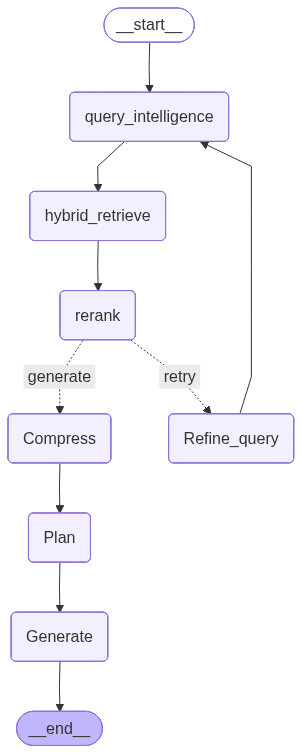

In [29]:
builder = StateGraph(GraphState)

builder.add_node("query_intelligence", query_intelligence_node)
builder.add_node("hybrid_retrieve", hybrid_retrieve_node)
builder.add_node("rerank", rerank_and_filter_node)
builder.add_node("Refine_query", Refine_query_node)
builder.add_node("Generate", generate_answer_node)
builder.add_node("Plan", answer_planning_node)
builder.add_node("Compress", compress_documents_node)

builder.set_entry_point("query_intelligence")

builder.add_edge("query_intelligence", "hybrid_retrieve")
builder.add_edge("hybrid_retrieve", "rerank")
builder.add_edge("Compress", "Plan")
builder.add_edge("Plan", "Generate")


builder.add_conditional_edges(
    "rerank",
    Retry_decision_logic,
    {
        "retry": "Refine_query",
        "generate": "Compress"
        # "generate": "generate"
    }
)

builder.add_edge("Refine_query", "query_intelligence")
builder.add_edge("Generate", END)

graph = builder.compile()

from IPython.display import Image, display # type: ignore
display(Image(graph.get_graph(xray=True).draw_mermaid_png()))

## Inferencing RAG

In [15]:
# "RAG systems retrieve documents before generation."),
#     Document(page_content="Faithfulness measures whether answers are grounded in retrieved documents."),
#     Document(page_content="Query expansion improves recall in retrieval systems."),

result = graph.invoke({
    # "query": "How do we measure faithfulness in computer terminal?",
    "query": "How does RAG ensure grounded generation despite irrelevant retrieved documents?",
    # "query": "How do we measure faithfulness in RAG LLM?",
    # "query": "how tall is the Eiffel Tower ?",
    # "query": "What is a RAG system?",
    # "query": "What is my favorite color?",
    # "query": "What is my name??",


    "iteration": 0
})
raw = result.get("answer", [])

if isinstance(raw, list) and len(raw) > 0:
    print(raw[0].get("text"))


Failed to send compressed multipart ingest: langsmith.utils.LangSmithAuthError: Authentication failed for https://api.smith.langchain.com/runs/multipart. HTTPError('401 Client Error: Unauthorized for url: https://api.smith.langchain.com/runs/multipart', '{"error":"Unauthorized"}\n')trace=019d5d64-bb37-7301-9174-96ad20d22363,id=019d5d64-bb37-7301-9174-96ad20d22363; trace=019d5d64-bb37-7301-9174-96ad20d22363,id=019d5d64-bb38-7f22-9548-2f2337f6cf60; trace=019d5d64-bb37-7301-9174-96ad20d22363,id=019d5d64-bb39-7f82-8f06-7e07b236f31b; trace=019d5d64-bb37-7301-9174-96ad20d22363,id=019d5d64-bb39-7f82-8f06-7e07b236f31b; trace=019d5d64-bb37-7301-9174-96ad20d22363,id=019d5d64-bb39-7f82-8f06-7e10dfa5f42b; trace=019d5d64-bb37-7301-9174-96ad20d22363,id=019d5d64-bb39-7f82-8f06-7e21521ad98d


----------------------------
Query:  What mechanisms and architectural strategies does Retrieval-Augmented Generation (RAG) employ to maintain factual grounding and mitigate hallucinations when the retrieved documents are noisy or irrelevant?
[Document(metadata={}, page_content='Latency increases when more documents are retrieved and processed.'), Document(metadata={}, page_content='Some retrieved documents may be irrelevant to the query.'), Document(metadata={}, page_content='Hallucination occurs when a model generates unsupported or incorrect information.'), Document(metadata={}, page_content='Hybrid retrieval combines dense and sparse methods for better performance.'), Document(metadata={}, page_content='Evaluation metrics for RAG include faithfulness, relevance, and answer correctness.'), Document(metadata={}, page_content='RAG systems retrieve relevant documents before generating responses.'), Document(metadata={}, page_content='Evaluation metrics for RAG include faithfulness, rel

KeyboardInterrupt: 

Failed to send compressed multipart ingest: langsmith.utils.LangSmithAuthError: Authentication failed for https://api.smith.langchain.com/runs/multipart. HTTPError('401 Client Error: Unauthorized for url: https://api.smith.langchain.com/runs/multipart', '{"error":"Unauthorized"}\n')trace=019d5d64-bb37-7301-9174-96ad20d22363,id=019d5d64-bb39-7f82-8f06-7e21521ad98d; trace=019d5d64-bb37-7301-9174-96ad20d22363,id=019d5d64-d1f0-7200-8d71-18a82679510c; trace=019d5d64-bb37-7301-9174-96ad20d22363,id=019d5d64-d1f0-7200-8d71-18a82679510c; trace=019d5d64-bb37-7301-9174-96ad20d22363,id=019d5d64-bb39-7f82-8f06-7e10dfa5f42b; trace=019d5d64-bb37-7301-9174-96ad20d22363,id=019d5d64-bb38-7f22-9548-2f2337f6cf60; trace=019d5d64-bb37-7301-9174-96ad20d22363,id=019d5d64-d1f1-72a3-a781-6873951e7525; trace=019d5d64-bb37-7301-9174-96ad20d22363,id=019d5d64-d1f2-7c63-a5f7-ffa67591890a; trace=019d5d64-bb37-7301-9174-96ad20d22363,id=019d5d64-d1f2-7c63-a5f7-ffa67591890a; trace=019d5d64-bb37-7301-9174-96ad20d22363,id